# COPD Gene Study Analysis in R

**Mia Saltzman**  
**STAT 200: Introduction to Data Science**

## Introduction

Chronic obstructive pulmonary disease (COPD) affects over 16 million Americans and is one of the leading causes of death in the United States. COPD is commonly associated with cigarette smoking and is typically evaluated using spirometry measurements, which measure how much air a person can forcefully exhale.

This project explores relationships between follow-up lung function measurements (`fev1_phase2`) and demographic, respiratory, and spirometry variables collected through the COPDGene research study. The analysis includes data cleaning, exploratory visualizations, statistical testing, and regression modeling using R.

## Skills Used

- R programming
- Data cleaning and transformation
- Exploratory data analysis
- Data visualization with `ggplot2`
- Statistical analysis
- Linear regression modeling
- Healthcare data interpretation


## 1. Load Packages


In [2]:
packages <- c("jsonlite", "rvest", "dplyr", "ggplot2", "broom", "knitr")

installed_packages <- rownames(installed.packages())

for (pkg in packages) {
  if (!(pkg %in% installed_packages)) {
    install.packages(pkg)
  }
}

library(jsonlite)
library(rvest)
library(dplyr)
library(ggplot2)
library(broom)
library(knitr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## 2. Import Data


- Demographic data (CSV file)
- Medical imaging data (JSON file)
- Spirometry data (HTML table)

Each dataset uses `sid` as the anonymous participant ID, which allows the files to be merged into one analysis-ready dataset.


In [3]:
demographics_url <- "https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_demographics.csv"
imaging_url <- "https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_imaging.json"
spirometry_url <- "https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_spirometry.html"

demographics <- read.csv(demographics_url)
imaging <- fromJSON(imaging_url)

spirometry_html <- read_html(spirometry_url)
spirometry <- spirometry_html %>%
  html_elements("table") %>%
  html_table() %>%
  .[[1]] %>%
  as.data.frame()

glimpse(demographics)
glimpse(imaging)
glimpse(spirometry)

Rows: 2,620
Columns: 18
$ sid                      <chr> "10005Q", "10055F", "10056H", "10060Y", "1006…
$ visit_year               <int> 2008, 2008, 2008, 2008, 2008, 2008, 2008, 200…
$ visit_date               <chr> "1/15/2008", "3/15/2008", "2/15/2008", "5/15/…
$ visit_age                <dbl> 54.5, 69.0, 48.7, 72.8, 76.2, 70.0, 61.8, 69.…
$ gender                   <int> 2, 1, 2, 1, 2, 2, 1, 2, 1, 1, 2, 2, 1, 2, 1, …
$ race                     <int> 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, …
$ smoking_status           <int> 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, …
$ height_cm                <dbl> 159.9, 178.0, 153.7, 177.0, 155.0, 165.1, 165…
$ weight_kg                <dbl> 73.0, 90.7, 86.2, 89.6, 55.0, 76.1, 85.0, 64.…
$ blood_pressure_systolic  <int> 130, 168, 100, 147, 134, 92, 108, 144, 139, 1…
$ blood_pressure_diastolic <int> 80, 100, 53, 71, 78, 58, 78, 90, 90, 75, 76, …
$ heart_rate               <int> 87, 55, 98, 87, 92, 77, 72, 110, 87, 73, 76, …
$ hours_on_oxyge

## 3. Clean Data


In [4]:
demographics_clean <- demographics %>%
  mutate(
    gender = factor(gender,
                    levels = c(1, 2),
                    labels = c("Male", "Female")),

    race = factor(race,
                  levels = c(1, 2, 3, 4, 5, 6),
                  labels = c("White",
                             "Black/African American",
                             "American Indian/Alaska Native",
                             "Asian",
                             "Native Hawaiian/Other Pacific Islander",
                             "More than one race")),

    smoking_status = factor(smoking_status,
                            levels = c(0, 1, 2),
                            labels = c("Never Smoker", "Former Smoker", "Current Smoker")),

    height_in = round(height_cm / 2.54, 2),
    weight_lbs = round(weight_kg * 2.20462, 2),

    hay_fever = ifelse(grepl("hayfever", respiratory, ignore.case = TRUE), "Yes", "No"),
    asthma = ifelse(grepl("asthma", respiratory, ignore.case = TRUE), "Yes", "No"),
    bronchitis_attacks = ifelse(grepl("bronchitis attacks", respiratory, ignore.case = TRUE), "Yes", "No"),
    chronic_bronchitis = ifelse(grepl("chronic bronchitis", respiratory, ignore.case = TRUE), "Yes", "No"),
    pneumonia = ifelse(grepl("pneumonia", respiratory, ignore.case = TRUE), "Yes", "No"),
    emphysema = ifelse(grepl("emphysema", respiratory, ignore.case = TRUE), "Yes", "No"),
    copd = ifelse(grepl("copd", respiratory, ignore.case = TRUE), "Yes", "No"),
    sleep_apnea = ifelse(grepl("sleep apnea", respiratory, ignore.case = TRUE), "Yes", "No")
  ) %>%
  select(-height_cm, -weight_kg, -respiratory) %>%
  mutate(across(c(hay_fever, asthma, bronchitis_attacks, chronic_bronchitis,
                  pneumonia, emphysema, copd, sleep_apnea), as.factor))

head(demographics_clean)

,sid,visit_year,visit_date,visit_age,gender,race,smoking_status,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,⋯,height_in,weight_lbs,hay_fever,asthma,bronchitis_attacks,chronic_bronchitis,pneumonia,emphysema,copd,sleep_apnea
,<chr>,<int>,<chr>,<dbl>,<fct>,<fct>,<fct>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,10005Q,2008,1/15/2008,54.5,Female,White,Current Smoker,130,80,87,⋯,62.95,160.94,No,No,No,No,No,No,No,No
2,10055F,2008,3/15/2008,69.0,Male,Black/African American,Former Smoker,168,100,55,⋯,70.08,199.96,No,No,No,No,No,No,No,No
3,10056H,2008,2/15/2008,48.7,Female,White,Former Smoker,100,53,98,⋯,60.51,190.04,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
4,10060Y,2008,5/15/2008,72.8,Male,White,Former Smoker,147,71,87,⋯,69.69,197.53,No,Yes,Yes,Yes,No,Yes,Yes,No
5,10068O,2008,3/15/2008,76.2,Female,White,Former Smoker,134,78,92,⋯,61.02,121.25,No,No,Yes,Yes,Yes,Yes,Yes,No
6,10072F,2008,3/15/2008,70.0,Female,White,Former Smoker,92,58,77,⋯,65.00,167.77,No,No,No,No,Yes,Yes,Yes,No


## 4. Merge Datasets

In [5]:
copd_data <- demographics_clean %>%
  full_join(imaging, by = "sid") %>%
  inner_join(spirometry, by = "sid")

cat("Number of participants in final dataset:", nrow(copd_data), "\n")
cat("Number of variables in final dataset:", ncol(copd_data), "\n")

head(copd_data)

Number of participants in final dataset: 2610 
Number of variables in final dataset: 35 


,sid,visit_year,visit_date,visit_age,gender,race,smoking_status,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,⋯,lung_volume_inspiratory,emphysema_percentage,lung_volume_expiratory,gas_trapping_percentage,mean_density_inspiratory,mean_density_expiratory,fev1_fvc_ratio,fev1,fvc,fev1_phase2
,<chr>,<int>,<chr>,<dbl>,<fct>,<fct>,<fct>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,10005Q,2008,1/15/2008,54.5,Female,White,Current Smoker,130,80,87,⋯,5.6636,0.9269,2.4766,6.8008,-830.343,-650.526,0.77,2.921,3.805,2.622
2,10055F,2008,3/15/2008,69.0,Male,Black/African American,Former Smoker,168,100,55,⋯,4.9060,1.9452,1.9057,10.6835,-823.746,-638.442,0.73,2.917,3.999,2.439
3,10056H,2008,2/15/2008,48.7,Female,White,Former Smoker,100,53,98,⋯,4.8654,11.3832,4.0606,47.8811,-836.281,-797.471,0.29,0.374,1.281,0.379
4,10060Y,2008,5/15/2008,72.8,Male,White,Former Smoker,147,71,87,⋯,7.3304,19.2623,5.3342,53.4747,-867.254,-821.256,0.29,0.706,2.424,1.405
5,10068O,2008,3/15/2008,76.2,Female,White,Former Smoker,134,78,92,⋯,6.0099,41.7757,4.1552,66.1621,-903.436,-856.337,0.46,0.806,1.736,0.580
6,10072F,2008,3/15/2008,70.0,Female,White,Former Smoker,92,58,77,⋯,3.9788,2.4735,2.8876,31.0631,-816.235,-747.113,0.57,1.573,2.752,1.477


## 5. Select Analysis Variables

The main outcome variable is `fev1_phase2`. The predictors include demographic characteristics, respiratory diagnoses, and baseline lung function measurements.


In [6]:
analysis_vars <- c(
  "fev1_phase2",
  "visit_age",
  "gender",
  "race",
  "smoking_status",
  "height_in",
  "weight_lbs",
  "bmi",
  "asthma",
  "copd",
  "fev1_fvc_ratio"
)

analysis_data <- copd_data %>%
  select(all_of(analysis_vars)) %>%
  na.omit()

cat("Complete cases used in analysis:", nrow(analysis_data), "\n")

summary(analysis_data)

Complete cases used in analysis: 2610 


  fev1_phase2      visit_age        gender    
 Min.   :0.379   Min.   :42.40   Male  :1327  
 1st Qu.:1.598   1st Qu.:52.70   Female:1283  
 Median :2.167   Median :59.95                
 Mean   :2.180   Mean   :59.97                
 3rd Qu.:2.742   3rd Qu.:66.70                
 Max.   :5.037   Max.   :81.00                
                                     race             smoking_status
 White                                 :1881   Never Smoker  :   0  
 Black/African American                : 729   Former Smoker :1407  
 American Indian/Alaska Native         :   0   Current Smoker:1203  
 Asian                                 :   0                        
 Native Hawaiian/Other Pacific Islander:   0                        
 More than one race                    :   0                        
   height_in       weight_lbs          bmi        asthma      copd     
 Min.   :52.64   Min.   : 82.45   Min.   :14.86   No :2155   No :1932  
 1st Qu.:64.03   1st Qu.:154.32   1st Qu.:24

## 6. Descriptive Statistics

The table below summarizes the main numeric variables used in the analysis.


In [7]:
numeric_summary <- analysis_data %>%
  select(where(is.numeric)) %>%
  summarise(across(
    everything(),
    list(
      mean = ~ mean(.x, na.rm = TRUE),
      sd = ~ sd(.x, na.rm = TRUE),
      min = ~ min(.x, na.rm = TRUE),
      max = ~ max(.x, na.rm = TRUE)
    )
  ))

kable(numeric_summary, digits = 2)



| fev1_phase2_mean| fev1_phase2_sd| fev1_phase2_min| fev1_phase2_max| visit_age_mean| visit_age_sd| visit_age_min| visit_age_max| height_in_mean| height_in_sd| height_in_min| height_in_max| weight_lbs_mean| weight_lbs_sd| weight_lbs_min| weight_lbs_max| bmi_mean| bmi_sd| bmi_min| bmi_max| fev1_fvc_ratio_mean| fev1_fvc_ratio_sd| fev1_fvc_ratio_min| fev1_fvc_ratio_max|
|----------------:|--------------:|---------------:|---------------:|--------------:|------------:|-------------:|-------------:|--------------:|------------:|-------------:|-------------:|---------------:|-------------:|--------------:|--------------:|--------:|------:|-------:|-------:|-------------------:|-----------------:|------------------:|------------------:|
|             2.18|           0.84|            0.38|            5.04|          59.97|          8.7|          42.4|            81|          66.97|         3.77|         52.64|         79.02|           184.5|         41.74|          82.45|         388.89|    2

## 7. Exploratory Visualizations

The following visualizations compare follow-up lung function across categorical variables and examine relationships with continuous variables.


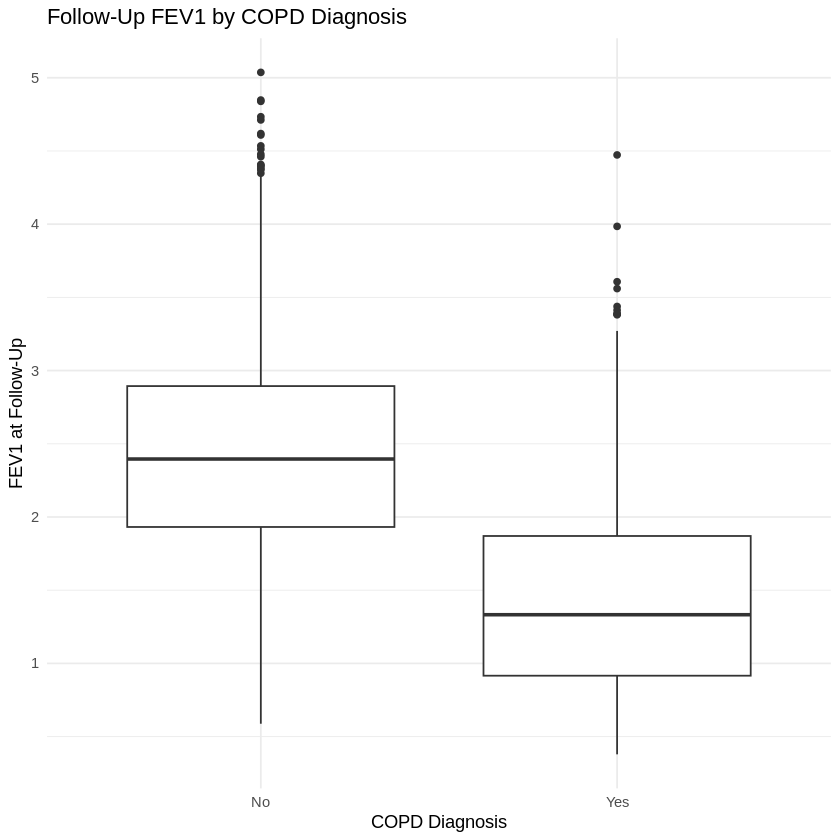

In [8]:
ggplot(analysis_data, aes(x = copd, y = fev1_phase2)) +
  geom_boxplot() +
  labs(
    title = "Follow-Up FEV1 by COPD Diagnosis",
    x = "COPD Diagnosis",
    y = "FEV1 at Follow-Up"
  ) +
  theme_minimal()

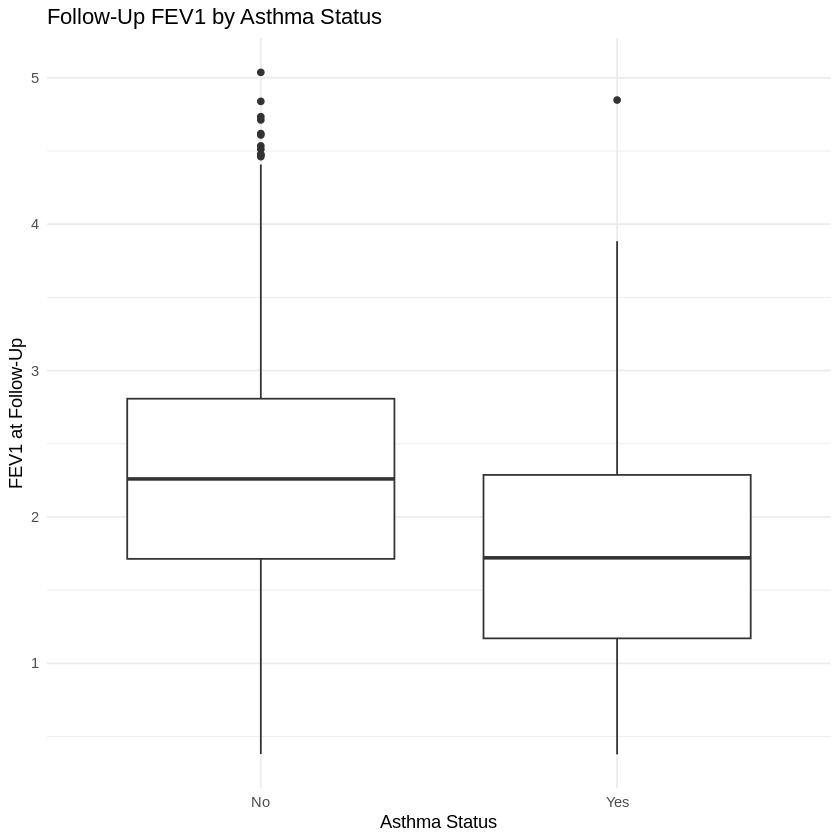

In [9]:
ggplot(analysis_data, aes(x = asthma, y = fev1_phase2)) +
  geom_boxplot() +
  labs(
    title = "Follow-Up FEV1 by Asthma Status",
    x = "Asthma Status",
    y = "FEV1 at Follow-Up"
  ) +
  theme_minimal()

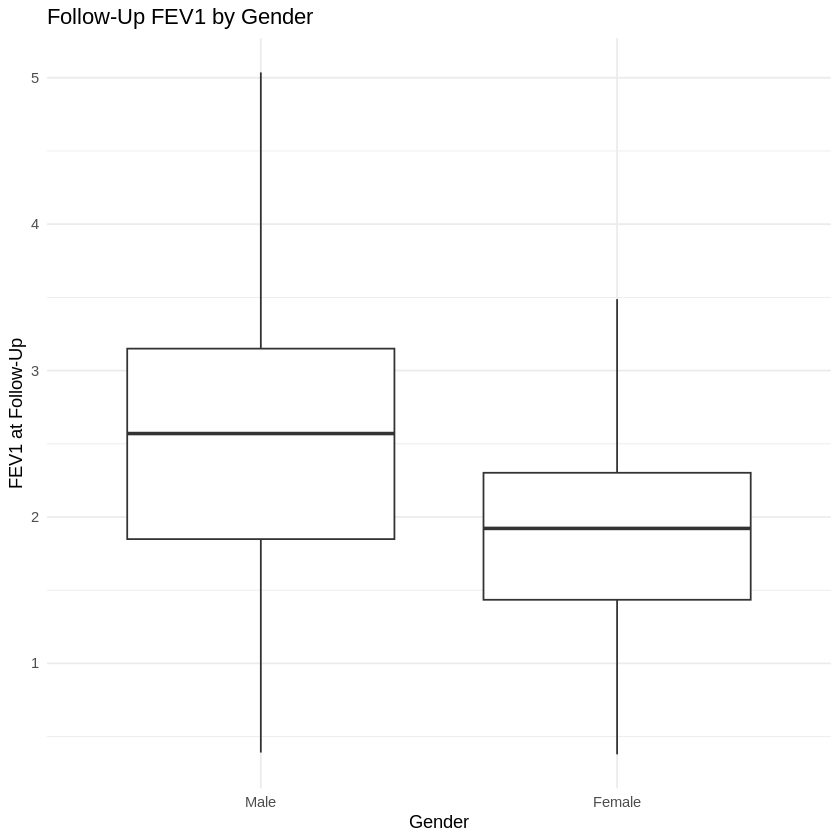

In [10]:
ggplot(analysis_data, aes(x = gender, y = fev1_phase2)) +
  geom_boxplot() +
  labs(
    title = "Follow-Up FEV1 by Gender",
    x = "Gender",
    y = "FEV1 at Follow-Up"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


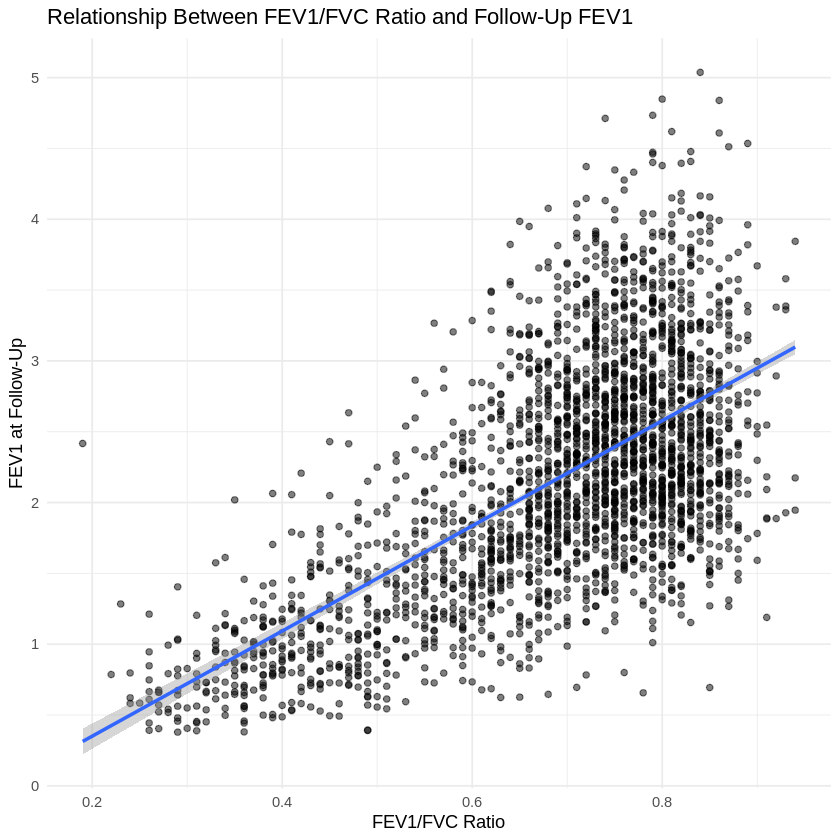

In [11]:
ggplot(analysis_data, aes(x = fev1_fvc_ratio, y = fev1_phase2)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Relationship Between FEV1/FVC Ratio and Follow-Up FEV1",
    x = "FEV1/FVC Ratio",
    y = "FEV1 at Follow-Up"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


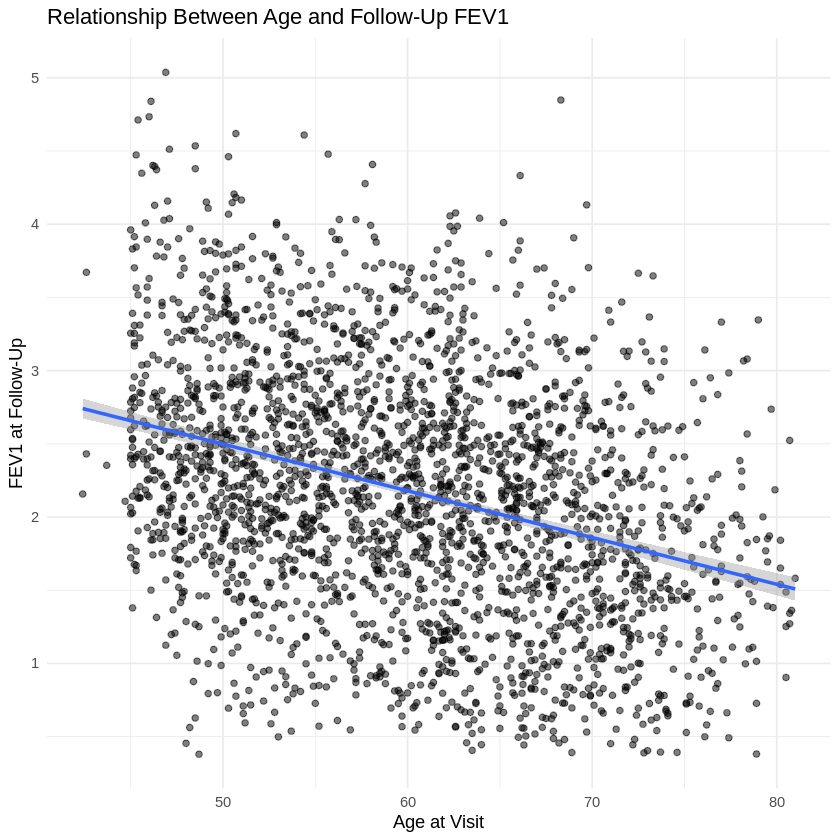

In [12]:
ggplot(analysis_data, aes(x = visit_age, y = fev1_phase2)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Relationship Between Age and Follow-Up FEV1",
    x = "Age at Visit",
    y = "FEV1 at Follow-Up"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


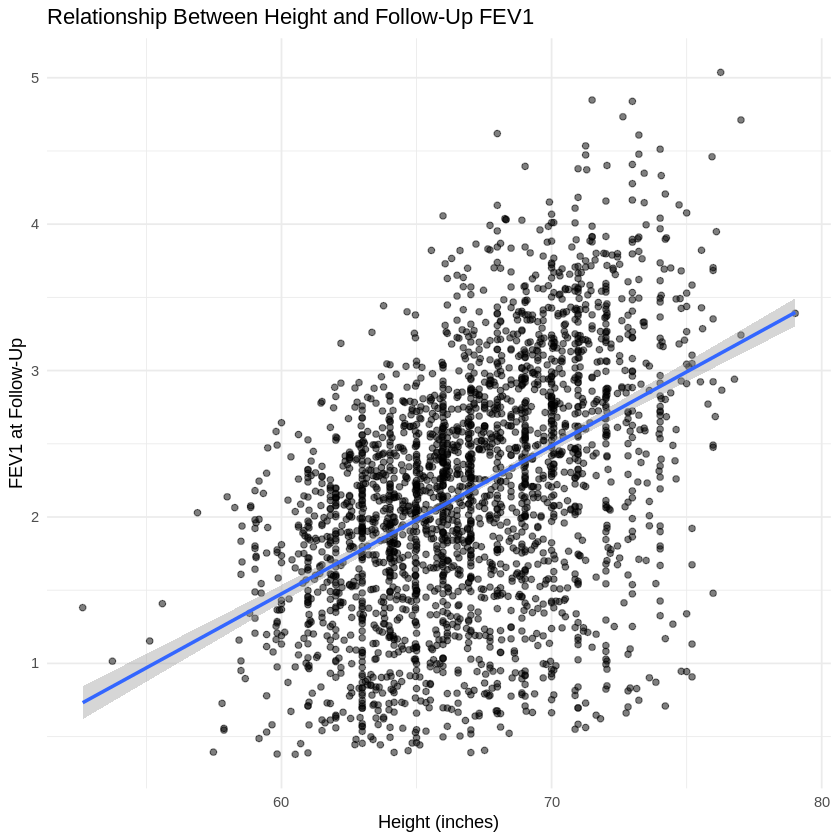

In [13]:
ggplot(analysis_data, aes(x = height_in, y = fev1_phase2)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Relationship Between Height and Follow-Up FEV1",
    x = "Height (inches)",
    y = "FEV1 at Follow-Up"
  ) +
  theme_minimal()

## 8. Group Comparisons

Welch two-sample t-tests were used to compare mean follow-up FEV1 between two-group categorical variables.


In [14]:
group_tests <- list(
  gender = t.test(fev1_phase2 ~ gender, data = analysis_data),
  asthma = t.test(fev1_phase2 ~ asthma, data = analysis_data),
  copd = t.test(fev1_phase2 ~ copd, data = analysis_data)
)

group_test_summary <- bind_rows(
  tidy(group_tests$gender) %>% mutate(variable = "gender"),
  tidy(group_tests$asthma) %>% mutate(variable = "asthma"),
  tidy(group_tests$copd) %>% mutate(variable = "copd")
) %>%
  select(variable, estimate1, estimate2, statistic, p.value, conf.low, conf.high)

kable(group_test_summary, digits = 4)



|variable | estimate1| estimate2| statistic| p.value| conf.low| conf.high|
|:--------|---------:|---------:|---------:|-------:|--------:|---------:|
|gender   |    2.4864|    1.8628|   20.6122|       0|   0.5643|    0.6830|
|asthma   |    2.2674|    1.7652|   12.4952|       0|   0.4232|    0.5811|
|copd     |    2.4349|    1.4531|   31.3892|       0|   0.9204|    1.0432|

## 9. Simple Linear Regression Models

Simple linear regression models were used to evaluate the relationship between follow-up FEV1 and each continuous predictor.


In [15]:
continuous_predictors <- c("visit_age", "height_in", "weight_lbs", "bmi", "fev1_fvc_ratio")

regression_results <- lapply(continuous_predictors, function(var) {
  model <- lm(as.formula(paste("fev1_phase2 ~", var)), data = analysis_data)

  tidy(model) %>%
    filter(term != "(Intercept)") %>%
    mutate(
      predictor = var,
      r_squared = glance(model)$r.squared,
      adj_r_squared = glance(model)$adj.r.squared
    )
}) %>%
  bind_rows() %>%
  select(predictor, estimate, std.error, statistic, p.value, r_squared, adj_r_squared)

kable(regression_results, digits = 4)



|predictor      | estimate| std.error| statistic| p.value| r_squared| adj_r_squared|
|:--------------|--------:|---------:|---------:|-------:|---------:|-------------:|
|visit_age      |  -0.0319|    0.0018|  -17.9621|  0.0000|    0.1101|        0.1097|
|height_in      |   0.1011|    0.0039|   26.1299|  0.0000|    0.2075|        0.2072|
|weight_lbs     |   0.0043|    0.0004|   11.2714|  0.0000|    0.0465|        0.0461|
|bmi            |  -0.0016|    0.0028|   -0.5849|  0.5587|    0.0001|       -0.0003|
|fev1_fvc_ratio |   3.7120|    0.0888|   41.7956|  0.0000|    0.4011|        0.4009|

## 10. Multiple Regression Model

A multiple regression model was created to evaluate follow-up lung function while accounting for several predictors at the same time.


In [16]:
multiple_model <- lm(
  fev1_phase2 ~ visit_age + height_in + weight_lbs + bmi + fev1_fvc_ratio + gender + asthma + copd,
  data = analysis_data
)

kable(tidy(multiple_model), digits = 4)
glance(multiple_model)



|term           | estimate| std.error| statistic| p.value|
|:--------------|--------:|---------:|---------:|-------:|
|(Intercept)    |  -3.4540|    0.8626|   -4.0042|  0.0001|
|visit_age      |  -0.0114|    0.0011|   -9.9629|  0.0000|
|height_in      |   0.0699|    0.0127|    5.4930|  0.0000|
|weight_lbs     |  -0.0004|    0.0022|   -0.1758|  0.8605|
|bmi            |  -0.0093|    0.0140|   -0.6636|  0.5070|
|fev1_fvc_ratio |   3.2326|    0.0886|   36.4945|  0.0000|
|genderFemale   |  -0.3663|    0.0262|  -13.9565|  0.0000|
|asthmaYes      |  -0.0976|    0.0255|   -3.8229|  0.0001|
|copdYes        |  -0.2431|    0.0277|   -8.7677|  0.0000|

r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.685708,0.6847413,0.4701143,709.3429,0,8,-1728.948,3477.895,3536.566,574.8404,2601,2610


## Abstract

Chronic Obstructive Pulmonary Disease (COPD) is recognized as one of the leading causes of death worldwide, affecting over 16 million Americans. The cause of COPD is most commonly credited to cigarette smoking, but can also be developed from various different factors. Disease severity is most commonly quantified using spirometry, where the volume of air forcefully exhaled (FEV1) indicates the level of harm to the body (less air exhaled suggests worse disease).

The purpose of this study was to analyze collected spirometry data from the COPDGene research group to determine which variables are most strongly associated with the Forced Expiratory Volume in one second five years after the initial visit (`fev1_phase2`). This report focuses on the `fev1_phase2` outcome variable and its relationship with categorical predictors including gender, race, smoking status, asthma, and COPD diagnosis, along with continuous predictors such as visit age, height, weight, BMI, and FEV1/FVC ratio.

The datasets were merged and cleaned before analysis. Box plots and scatterplots were used to visualize relationships between variables, while t-tests and simple linear regression models were used to evaluate statistical significance.

The analysis showed that participants diagnosed with COPD had substantially lower `fev1_phase2` values compared to participants without COPD. The FEV1/FVC ratio demonstrated the strongest positive relationship with follow-up lung function, while age showed a negative relationship with lung function over time. Height also showed a positive association with `fev1_phase2`, while BMI demonstrated little to no meaningful relationship.

Overall, the findings suggest that baseline spirometry measurements and COPD status are among the strongest predictors of long-term pulmonary function in COPDGene participants.

## Data Sources

  * [demographics data](https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_demographics.csv)
  * [medical image data](https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_imaging.json)
  * [spirometry data](https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_spirometry.html)